In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tsfresh
from tsfresh import extract_relevant_features, select_features
from tsfresh.feature_extraction import extract_features
from tsfresh.utilities.dataframe_functions import impute
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [46]:
# Parameters
n_series_per_class = 50
series_length = 100
noise_level = 0.2

data = []
ids = []
times = []
labels = []

current_id = 0
t = np.linspace(0, 2 * np.pi, series_length)

# -------- CLASS 0: Clean sine --------
for _ in range(n_series_per_class):
    y = np.sin(t)
    data.extend(y)
    ids.extend([current_id] * series_length)
    times.extend(range(series_length))
    labels.append(0)
    current_id += 1

# -------- CLASS 1: Noisy sine --------
for _ in range(n_series_per_class):
    y = np.sin(t) + np.random.normal(0, noise_level, size=series_length)
    data.extend(y)
    ids.extend([current_id] * series_length)
    times.extend(range(series_length))
    labels.append(1)
    current_id += 1

# -------- CLASS 2: Square wave --------
for _ in range(n_series_per_class):
    y = np.sign(np.sin(t))
    data.extend(y)
    ids.extend([current_id] * series_length)
    times.extend(range(series_length))
    labels.append(2)
    current_id += 1

# -------- CLASS 3: Shifted sine --------
for _ in range(n_series_per_class):
    shift = np.random.uniform(0, np.pi)
    y = np.sin(t + shift)
    data.extend(y)
    ids.extend([current_id] * series_length)
    times.extend(range(series_length))
    labels.append(3)
    current_id += 1

# -------- CLASS 4: Scaled sine --------
for _ in range(n_series_per_class):
    scale = np.random.uniform(0.5, 2.0)
    y = scale * np.sin(t)
    data.extend(y)
    ids.extend([current_id] * series_length)
    times.extend(range(series_length))
    labels.append(4)
    current_id += 1

# Create DataFrame (TSFresh format)
df = pd.DataFrame({
    "id": ids,
    "time": times,
    "value": data
})

# Labels (one per series)
y = pd.Series(labels, name="target")

print(df)
print(y)

        id  time         value
0        0     0  0.000000e+00
1        0     1  6.342392e-02
2        0     2  1.265925e-01
3        0     3  1.892512e-01
4        0     4  2.511480e-01
...    ...   ...           ...
24995  249    95 -4.240954e-01
24996  249    96 -3.195749e-01
24997  249    97 -2.137675e-01
24998  249    98 -1.070994e-01
24999  249    99 -4.135945e-16

[25000 rows x 3 columns]
0      0
1      0
2      0
3      0
4      0
      ..
245    4
246    4
247    4
248    4
249    4
Name: target, Length: 250, dtype: int64


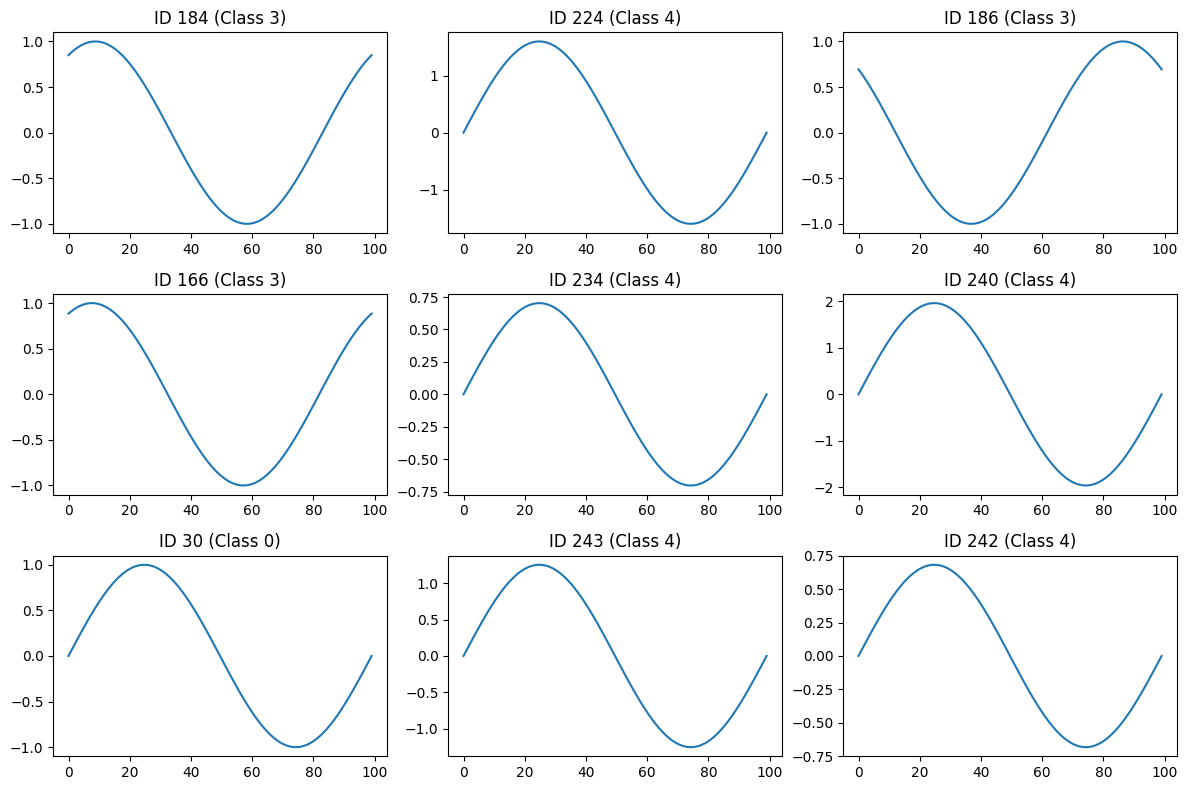

In [47]:
n_examples = 9

# randomly sample IDs instead of taking the first ones
example_ids = np.random.choice(df["id"].unique(), size=n_examples, replace=False)

plt.figure(figsize=(12, 8))

for i, series_id in enumerate(example_ids):
    plt.subplot(3, 3, i + 1)
    
    subset = df[df["id"] == series_id]
    label = y.iloc[series_id]
    
    plt.plot(subset["time"], subset["value"])
    plt.title(f"ID {series_id} (Class {label})")

plt.tight_layout()
plt.show()

In [48]:
X = extract_features(df, column_id="id", column_sort="time")
X = X.dropna(axis=1)
X_selected = select_features(X, y)

Feature Extraction: 100%|██████████| 42/42 [00:04<00:00,  8.62it/s]


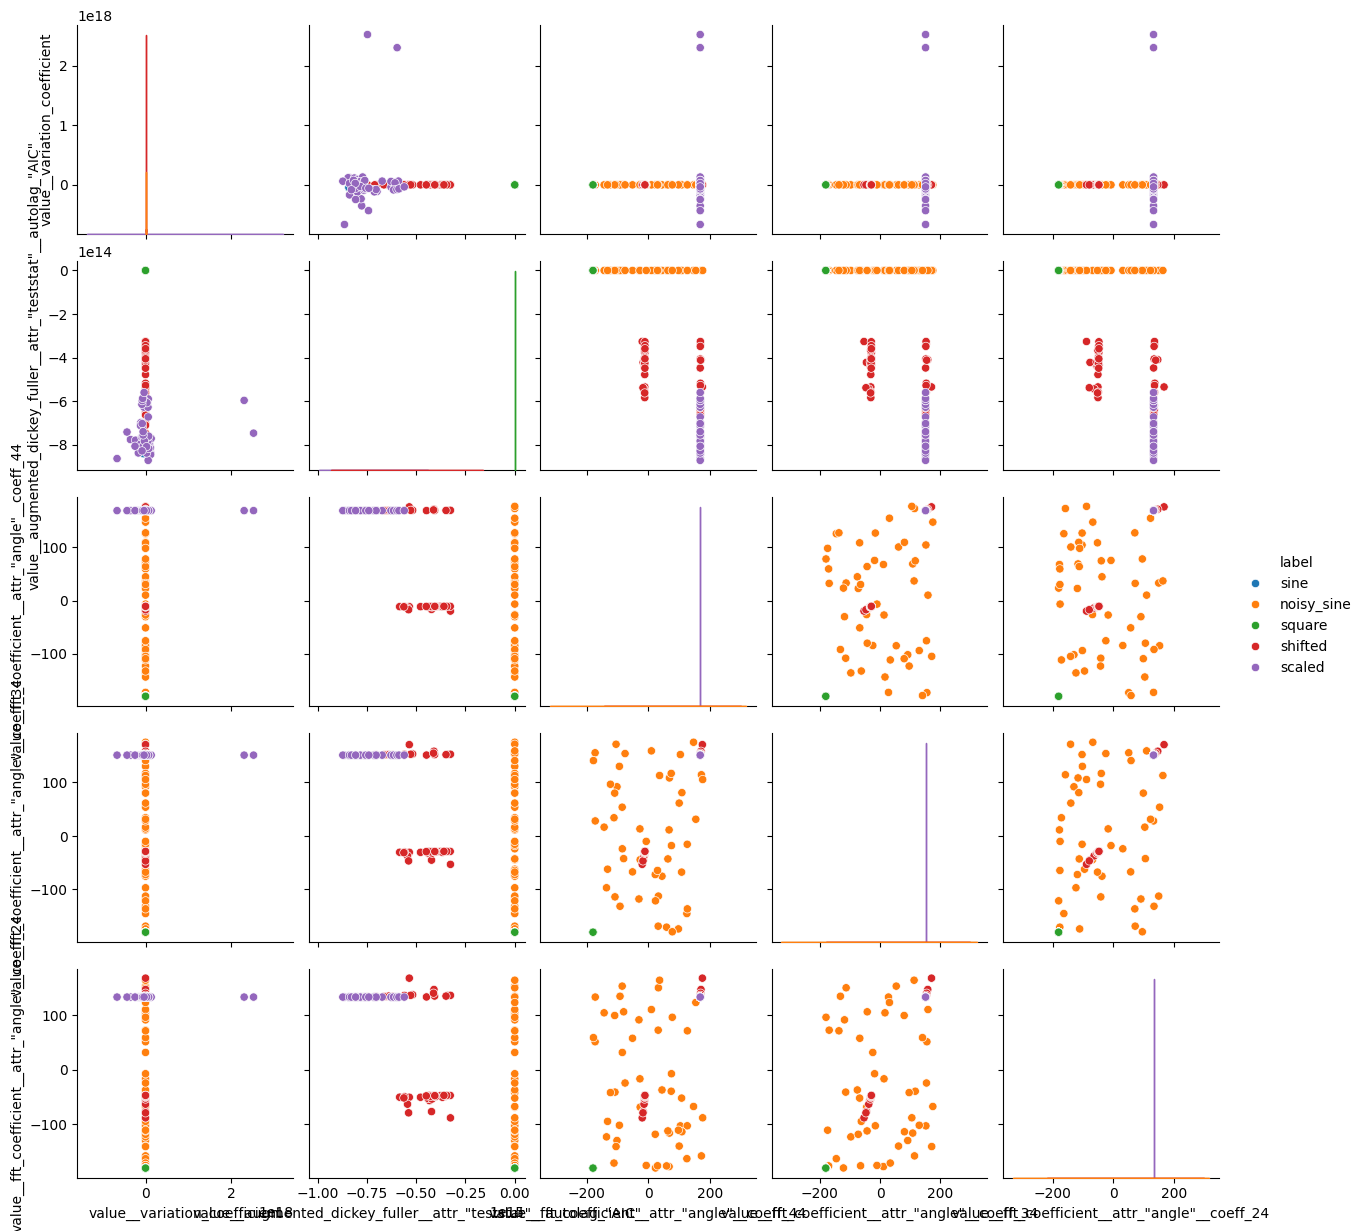

In [49]:
X = X_selected

# simple variance proxy (since TSFresh already filtered relevance)
feature_scores = X.var().sort_values(ascending=False)

top5_features = feature_scores.head(5).index
label_names = {
    0: "sine",
    1: "noisy_sine",
    2: "square",
    3: "shifted",
    4: "scaled"
}

X_top5 = X[top5_features]

plot_df = X_top5.copy()
plot_df["label"] = y.map(label_names)

sns.pairplot(plot_df, hue="label")
plt.show()

In [50]:
forest = RandomForestClassifier()

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10)

scores = cross_val_score(forest, X_top5, y, cv=cv, scoring='accuracy')

print("Mean accuracy:", np.mean(scores))
print("Std:", np.std(scores))

Mean accuracy: 0.9956
Std: 0.012515590277729624
